# Synthetic Data Generation Using RAGAS - RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow!



- 🤝 BREAKOUT ROOM #1
  1. Use RAGAS to Generate Synthetic Data

- 🤝 BREAKOUT ROOM #2
  1. Load them into a LangSmith Dataset
  2. Evaluate our RAG chain against the synthetic test data
  3. Make changes to our pipeline
  4. Evaluate the modified pipeline

SDG is a critical piece of the puzzle, especially for early iteration! Without it, it would not be nearly as easy to get high quality early signal for our application's performance.

Let's dive in!

# 🤝 BREAKOUT ROOM #1

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ashimamangla/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ashimamangla/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [20]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Use-Case Data!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [5]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [6]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [7]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [8]:
from ragas.testset.graph import Node, NodeType

### NOTICE: We're using a subset of the data for this example - this is to keep costs/time down.
for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 64, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [9]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node 'd01769'. Skipping!
Property 'summary' already exists in node '1af256'. Skipping!
Property 'summary' already exists in node 'bb53d2'. Skipping!
Property 'summary' already exists in node '20020b'. Skipping!
Property 'summary' already exists in node '645f13'. Skipping!
Property 'summary' already exists in node 'f33434'. Skipping!
Property 'summary' already exists in node 'bf90cd'. Skipping!
Property 'summary' already exists in node 'ebb2a4'. Skipping!
Property 'summary' already exists in node '27083b'. Skipping!
Property 'summary' already exists in node '704969'. Skipping!
Property 'summary' already exists in node 'ff8d50'. Skipping!
Property 'summary' already exists in node '5522e8'. Skipping!
Property 'summary' already exists in node 'c7fbc5'. Skipping!
Property 'summary' already exists in node '5df46a'. Skipping!
Property 'summary' already exists in node 'f68837'. Skipping!
Property 'summary' already exists in node 'f77a8f'. Skipping!
Property

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/48 [00:00<?, ?it/s]

Property 'summary_embedding' already exists in node 'ff8d50'. Skipping!
Property 'summary_embedding' already exists in node 'ebb2a4'. Skipping!
Property 'summary_embedding' already exists in node '27083b'. Skipping!
Property 'summary_embedding' already exists in node 'bb53d2'. Skipping!
Property 'summary_embedding' already exists in node '645f13'. Skipping!
Property 'summary_embedding' already exists in node 'd01769'. Skipping!
Property 'summary_embedding' already exists in node 'bf90cd'. Skipping!
Property 'summary_embedding' already exists in node '1af256'. Skipping!
Property 'summary_embedding' already exists in node 'c7fbc5'. Skipping!
Property 'summary_embedding' already exists in node 'f33434'. Skipping!
Property 'summary_embedding' already exists in node '20020b'. Skipping!
Property 'summary_embedding' already exists in node '704969'. Skipping!
Property 'summary_embedding' already exists in node '5522e8'. Skipping!
Property 'summary_embedding' already exists in node 'f68837'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 86, relationships: 711)

We can save and load our knowledge graphs as follows.

In [11]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 86, relationships: 711)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [12]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [13]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

#### ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.


##### ✅ Answer:
SingleHopSpecificQuerySynthesizer: Creates factual questions that can be answered in one-hop requiring only one lookup from the information provided to find the answer . The 0.5 means that this will be half the number of queries generated will be single hop kind so this represents the distribution weight of the number of queries of this kind among all queries generated.

MultiHopAbstractQuerySynthesizer: This synthesizer will produce queries requiring multi-step reasoning to answer. It prompts the RAG system to find info across multiple documents or sections to generate a response. 
The ideas is to test the system's ability to reason from information from different parts of the knowledge base. 0.25 means that a fourth of the queries will be generated by this method

MultiHopSpecificQuerySynthesizer: This synthesizer is similar to the MultiHopAbstract synthesizer but focusses on creating questions that link concrete facts across documents. The purpose is to evaluate the system's ability to retrieve information about a specific subject from a document and connect it to information about the same subject in another document.  So the main difference between thte two multihop synthesizers are 'abstract' and 'concrete'


Finally, we can use our `TestSetGenerator` to generate our testset!

In [14]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,How many users are there with 700 million user...,[Introduction ChatGPT launched in November 202...,"By July 2025, there are 700 million users of C...",single_hop_specifc_query_synthesizer
1,What is the significance of June 2025 in ChatG...,[Table 1: ChatGPT daily message counts (millio...,The context reports that the 7-day average of ...,single_hop_specifc_query_synthesizer
2,What are nonprofessional occupations?,[Variation by Occupation Figure 23 presents va...,Variation by Occupation Figure 23 presents var...,single_hop_specifc_query_synthesizer
3,What significance does November 2022 hold in t...,[Conclusion This paper studies the rapid growt...,"ChatGPT launched in November 2022, marking the...",single_hop_specifc_query_synthesizer
4,H0w does privaacy-preserving aggreation limts ...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The context explains that due to privacy-prese...,multi_hop_abstract_query_synthesizer
5,How does the message percentage distribution f...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"In Jun 2024, non-work messages accounted for 5...",multi_hop_abstract_query_synthesizer
6,How does the message volume comparison between...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"The data shows that in June 2024, non-work mes...",multi_hop_abstract_query_synthesizer
7,"Considering the rapid growth of ChatGPT, which...",[<1-hop>\n\nConclusion This paper studies the ...,"The extensive message volume, with over 18 bil...",multi_hop_specific_query_synthesizer
8,How does the data privacy methodology used in ...,[<1-hop>\n\nConclusion This paper studies the ...,The data privacy methodology employed in study...,multi_hop_specific_query_synthesizer
9,Considering the rapid growth of ChatGPT usage ...,[<1-hop>\n\nConclusion This paper studies the ...,"The widespread adoption of ChatGPT in the US, ...",multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [15]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node '99ae85'. Skipping!
Property 'summary' already exists in node 'd6ec5e'. Skipping!
Property 'summary' already exists in node 'a50863'. Skipping!
Property 'summary' already exists in node '80087b'. Skipping!
Property 'summary' already exists in node '8a84b7'. Skipping!
Property 'summary' already exists in node 'c65454'. Skipping!
Property 'summary' already exists in node 'a9cabe'. Skipping!
Property 'summary' already exists in node 'a93543'. Skipping!
Property 'summary' already exists in node '40f93e'. Skipping!
Property 'summary' already exists in node '39a0e4'. Skipping!
Property 'summary' already exists in node 'e594eb'. Skipping!
Property 'summary' already exists in node '07eba7'. Skipping!
Property 'summary' already exists in node '38cdda'. Skipping!
Property 'summary' already exists in node '273cb0'. Skipping!
Property 'summary' already exists in node '28e0f5'. Skipping!
Property 'summary' already exists in node 'f33685'. Skipping!
Property

...

Property 'summary_embedding' already exists in node '8a84b7'. Skipping!
Property 'summary_embedding' already exists in node '80087b'. Skipping!
Property 'summary_embedding' already exists in node 'a50863'. Skipping!
Property 'summary_embedding' already exists in node 'a93543'. Skipping!
Property 'summary_embedding' already exists in node 'a9cabe'. Skipping!
Property 'summary_embedding' already exists in node '99ae85'. Skipping!
Property 'summary_embedding' already exists in node '40f93e'. Skipping!
Property 'summary_embedding' already exists in node 'e594eb'. Skipping!
Property 'summary_embedding' already exists in node '39a0e4'. Skipping!
Property 'summary_embedding' already exists in node 'c65454'. Skipping!
Property 'summary_embedding' already exists in node 'd6ec5e'. Skipping!
Property 'summary_embedding' already exists in node '07eba7'. Skipping!
Property 'summary_embedding' already exists in node '38cdda'. Skipping!
Property 'summary_embedding' already exists in node '273cb0'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [19]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,"What does Bick et al., 2024, contribute to und...",[Introduction ChatGPT launched in November 202...,"Bick et al., 2024, report that ChatGPT launche...",single_hop_specifc_query_synthesizer
1,tell me how ChatGPT is used like in daily mess...,[Table 1: ChatGPT daily message counts (millio...,Table 1 shows that ChatGPT's daily message cou...,single_hop_specifc_query_synthesizer
2,How does the usage of ChatGPT vary among diffe...,[Variation by Occupation Figure 23 presents va...,Variation by Occupation Figure 23 presents var...,single_hop_specifc_query_synthesizer
3,What is the significance of July 2025 in ChatG...,[Conclusion This paper studies the rapid growt...,"By July 2025, ChatGPT had been used weekly by ...",single_hop_specifc_query_synthesizer
4,how gender and age gaps in usage matter for Ch...,[<1-hop>\n\nConclusion This paper studies the ...,The context indicates that gender gaps in Chat...,multi_hop_abstract_query_synthesizer
5,how chatgpt use differ by occupation and how t...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,Variation by occupation shows that users in hi...,multi_hop_abstract_query_synthesizer
6,How do work-related message sharing and usage ...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The context indicates that users in highly pai...,multi_hop_abstract_query_synthesizer
7,How does privacy-preserving data aggregation i...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The context indicates that due to privacy-pres...,multi_hop_abstract_query_synthesizer
8,wHAT is the mOON in JULY 2025?,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"The context indicates that by July 2025, ChatG...",multi_hop_specific_query_synthesizer
9,"how many messages like 2.5 billion messages, a...",[<1-hop>\n\nIntroduction ChatGPT launched in N...,"According to the context, by July 2025, ChatGP...",multi_hop_specific_query_synthesizer


We'll need to provide our LangSmith API key, and set tracing to "true".

# 🤝 BREAKOUT ROOM #2

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [24]:
from langsmith import Client

dataset_name = "Use Case Synthetic Data - AIE8-Ashima"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [25]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [26]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [27]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [28]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [29]:
from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG"
)

In [30]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [31]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [33]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [35]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [37]:
rag_chain.invoke({"question" : "What are people doing with AI these days?"})

'Based on the provided context, people are using AI, particularly generative AI like ChatGPT, in many different ways. They use it to perform workplace tasks, either by augmenting or automating human labor. AI is flexible and can produce writing, software code, spreadsheets, and other digital products, distinguishing it from traditional web search engines. People also use AI to ask questions, get advice, and improve productivity in problem-solving. Additionally, use cases include activities related to relationships, personal reflection, games, and role play, though these are smaller proportions. Overall, AI serves both as a co-worker producing output and as a co-pilot advising and enhancing human work.\n\nIn summary, people are using AI to assist with work-related tasks, generate creative and digital content, seek information and advice, automate or improve productivity, and even for self-expression and entertainment.'

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [38]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [39]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "dopeness": "Is this response dope, lit, cool, or is it just a generic response?",
        },
        "llm" : eval_llm
    }
)

#### 🏗️ Activity #2:

Highlight what each evaluator is evaluating.

- `qa_evaluator`:
- `labeled_helpfulness_evaluator`:
- `dopeness_evaluator`:

##### ✅ Answer:
qa_evaluator: qa stands for Question-Answer . This evaluator will take a question and an answer which has been llm generated and uses the specified eval_llm to analyze whether the answer is correct and completetly address the question and returns a score between 0 and 1 . Higher the better quality

labeled_helpfulness_evaluator: is a custom evaluator defined using LangChainStringEvaluator. It measures how helpful a response is to the user, comparing it with the correct reference answer provided. It uses the eval_llm to score the criteria between 0 and 1 

dopeness_evaluator: is a custom evaluator defined using LangChainStringEvaluator. It measures how dope a response is to the userusing the eval_llm to judge and score the criteria between 0 and 1 (no reference answer provided)

## LangSmith Evaluation

In [40]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'dear-shame-77' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/e32cdd07-955a-4721-bde8-1a4f745f1cd6/compare?selectedSessions=5b95ab66-aaf7-4061-a94e-04a44b9e128c




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"Based on the findings of Handa et al. (2025), ...",Based on the provided context from Handa et al...,None,Handa et al. (2025) report that nearly 80% of ...,1,1,0,7.467156,e75340d3-d483-4486-a98e-808108b76918,2fe6874e-61b8-4ba7-ae0f-123216b7a922
1,How does Handa et al. (2025) describe the grow...,I don't know.,None,"Handa et al. (2025) report that by July 2025, ...",0,0,0,1.281495,4e150c56-1596-433f-a84d-59264253a59d,c1f23ada-c29b-49ea-97c7-8e2523089916
2,"how many messages like 2.5 billion messages, a...",Based on the provided context:\n\n- By July 20...,None,"According to the context, by July 2025, ChatGP...",1,0,0,5.977342,4f829558-9ae3-4054-8cfa-f44df7ecb0ea,7d717c77-9e4d-45ab-9e87-8252780a4e0a
3,wHAT is the mOON in JULY 2025?,I don't know.,None,"The context indicates that by July 2025, ChatG...",1,0,0,1.842316,d6ff91fc-cf2c-4063-931d-f8030c178ff3,6818951a-ebe8-4b00-b0e0-a4f30f544f33
4,How does privacy-preserving data aggregation i...,"Based on the provided context, privacy-preserv...",None,The context indicates that due to privacy-pres...,1,1,0,4.505794,f01dcf02-32a7-4a1c-9c3a-a83eaf8696ee,e0e76c03-369c-4ed0-958a-5e8bb0d7f1a0
5,How do work-related message sharing and usage ...,"Based on the provided context, the differences...",None,The context indicates that users in highly pai...,1,1,0,7.714789,cfff26d6-d327-4e67-9968-411b83edf694,3e37dabe-c0a6-4e5f-9215-08b0329780cd
6,how chatgpt use differ by occupation and how t...,"Based on the provided context, ChatGPT usage v...",None,Variation by occupation shows that users in hi...,1,1,0,5.861897,0d05bbc2-4c3f-42bc-b6ab-28f21cee726b,d6467e91-3d8f-47b8-a4a7-0b524e23c785
7,how gender and age gaps in usage matter for Ch...,"Based on the provided context, here is what we...",None,The context indicates that gender gaps in Chat...,1,1,0,7.987183,75ea5ecb-dabf-47ab-a548-a5a72295034b,0d834ee9-a44d-482b-a780-cfc3205a19a7
8,What is the significance of July 2025 in ChatG...,July 2025 is significant in ChatGPT usage anal...,None,"By July 2025, ChatGPT had been used weekly by ...",1,0,0,2.761504,5394a045-b8a9-47ae-a058-510f9cb9b6de,5572c08e-0b83-40c6-9d39-d88c850d410d
9,How does the usage of ChatGPT vary among diffe...,"According to the provided context, users in co...",None,Variation by Occupation Figure 23 presents var...,1,0,0,3.778656,66a437f2-a8f7-4aa2-84f3-88a6b2668388,45fa1a7b-2f43-4f06-a972-47c7a20fb5ff


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [41]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [42]:
rag_documents = docs

In [43]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

#### ❓Question #2:

Why would modifying our chunk size modify the performance of our application?

##### ✅ Answer:
(1) Larger chunksize will capture greater context (2) Also an overlap will ensure context continuity Both these help to ensure connected answers (3) it will impact the performance (memory/compute) negatively

In [45]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

#### ❓Question #3:

Why would modifying our embedding model modify the performance of our application?

##### ✅ Answer: 
We are changing from  smaller model to a higher dimensional model which models more dimensions and hence will have finer granularity and will be more accurate - it will also require more compute and memory resources. 

In [44]:
vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [46]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [49]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [50]:
dopeness_rag_chain.invoke({"question" : "How are people using AI to make money?"})

"Alright, buckle up—here’s the lowdown on how folks are cashing in with AI, straight from the freshest insights in the wild world of generative AI usage:\n\nPeople aren’t just using AI as a glorified calculator; they’re turning ChatGPT and buddies into their personal workplace sidekicks. It’s less about AI doing their jobs outright and more about AI *boosting* their decision-making game—especially in knowledge-heavy gigs where sharp choices make bank. Think of ChatGPT as the slick advisor or research assistant who cranks up your productivity mojo.\n\nThis dynamic isn’t some fringe vibe: Collis and Brynjolfsson’s 2025 research paints a vivid picture of the value AI adds. They estimate Americans would literally need to be paid a cool $98 just to *not* use generative AI for a month. We're talking at least $97 billion a year in extra surplus, baby! That kinda dough shows AI isn't just a tool—it’s an economic powerhouse that pumps up worker output by making knowledge work smarter, not harde

Finally, we can evaluate the new chain on the same test set!

In [51]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'sunny-chalk-92' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/e32cdd07-955a-4721-bde8-1a4f745f1cd6/compare?selectedSessions=0d234477-8fe1-4b9d-8fa7-979828d804a1




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"Based on the findings of Handa et al. (2025), ...","Oh, buckle up — this one’s a wild dive into ho...",None,Handa et al. (2025) report that nearly 80% of ...,1,1,1,6.016176,e75340d3-d483-4486-a98e-808108b76918,747e1246-9c73-4019-8483-d438cadc3d82
1,How does Handa et al. (2025) describe the grow...,"Yo, here’s the lowdown straight from the fresh...",None,"Handa et al. (2025) report that by July 2025, ...",1,0,1,4.702536,4e150c56-1596-433f-a84d-59264253a59d,557703ea-6b98-48b6-b458-7dad93f9c1e9
2,"how many messages like 2.5 billion messages, a...","Alright, let’s crank this up to eleven. Based ...",None,"According to the context, by July 2025, ChatGP...",1,0,1,9.424996,4f829558-9ae3-4054-8cfa-f44df7ecb0ea,b7abf7d3-9d5d-4427-becb-bf5758d431aa
3,wHAT is the mOON in JULY 2025?,"Yo, the context you dropped is pure gold about...",None,"The context indicates that by July 2025, ChatG...",1,1,1,3.016633,d6ff91fc-cf2c-4063-931d-f8030c178ff3,210630fc-a509-40b9-9fe3-bf57b8de1bb3
4,How does privacy-preserving data aggregation i...,"Alright, buckle up for some next-level insight...",None,The context indicates that due to privacy-pres...,1,1,1,7.167195,f01dcf02-32a7-4a1c-9c3a-a83eaf8696ee,7f325424-acba-4615-b55e-bf5951ab4a9a
5,How do work-related message sharing and usage ...,"Yo, buckle up—here’s the ultra-dopeness on how...",None,The context indicates that users in highly pai...,1,1,1,8.803420,cfff26d6-d327-4e67-9968-411b83edf694,14754d84-6a0f-443a-be23-9cd4dc33ddf7
6,how chatgpt use differ by occupation and how t...,"Yo, let’s dive deep into the wicked cool vibes...",None,Variation by occupation shows that users in hi...,1,1,1,8.657685,0d05bbc2-4c3f-42bc-b6ab-28f21cee726b,eec19365-2783-43cd-aefa-7eef6df4cb82
7,how gender and age gaps in usage matter for Ch...,"Alright, let’s dive into the rad truth about h...",None,The context indicates that gender gaps in Chat...,1,1,1,6.652901,75ea5ecb-dabf-47ab-a548-a5a72295034b,b3a88074-b673-4733-a089-981b38782253
8,What is the significance of July 2025 in ChatG...,"Alright, buckle up for the dopest drop of AI i...",None,"By July 2025, ChatGPT had been used weekly by ...",1,1,1,8.592800,5394a045-b8a9-47ae-a058-510f9cb9b6de,66f8878f-6ce7-49b8-907d-e93af3548973
9,How does the usage of ChatGPT vary among diffe...,"Yo, here’s the lowdown straight from the digit...",None,Variation by Occupation Figure 23 presents var...,1,0,1,5.738961,66a437f2-a8f7-4aa2-84f3-88a6b2668388,df72c3e1-29c8-4894-8c50-806ba0df02d9


#### 🏗️ Activity #3:

Provide a screenshot of the difference between the two chains, and explain why you believe certain metrics changed in certain ways.

##### ✅ Answer: 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Run evaluations and store results
# Run evaluations and store results
regular_eval = evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[qa_evaluator, labeled_helpfulness_evaluator, dopeness_evaluator],
    metadata={"revision_id": "regular_rag_chain"},
)

dopeness_eval = evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[qa_evaluator, labeled_helpfulness_evaluator, dopeness_evaluator],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'vacant-hole-51' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/e32cdd07-955a-4721-bde8-1a4f745f1cd6/compare?selectedSessions=0e8cd798-b8d2-4f8a-9099-7dcdd6bfd809




0it [00:00, ?it/s]

View the evaluation results for experiment: 'notable-class-15' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/e32cdd07-955a-4721-bde8-1a4f745f1cd6/compare?selectedSessions=d00becc7-3125-454c-9c3f-3aaca619247b




0it [00:00, ?it/s]

AttributeError: 'ExperimentResults' object has no attribute 'results'

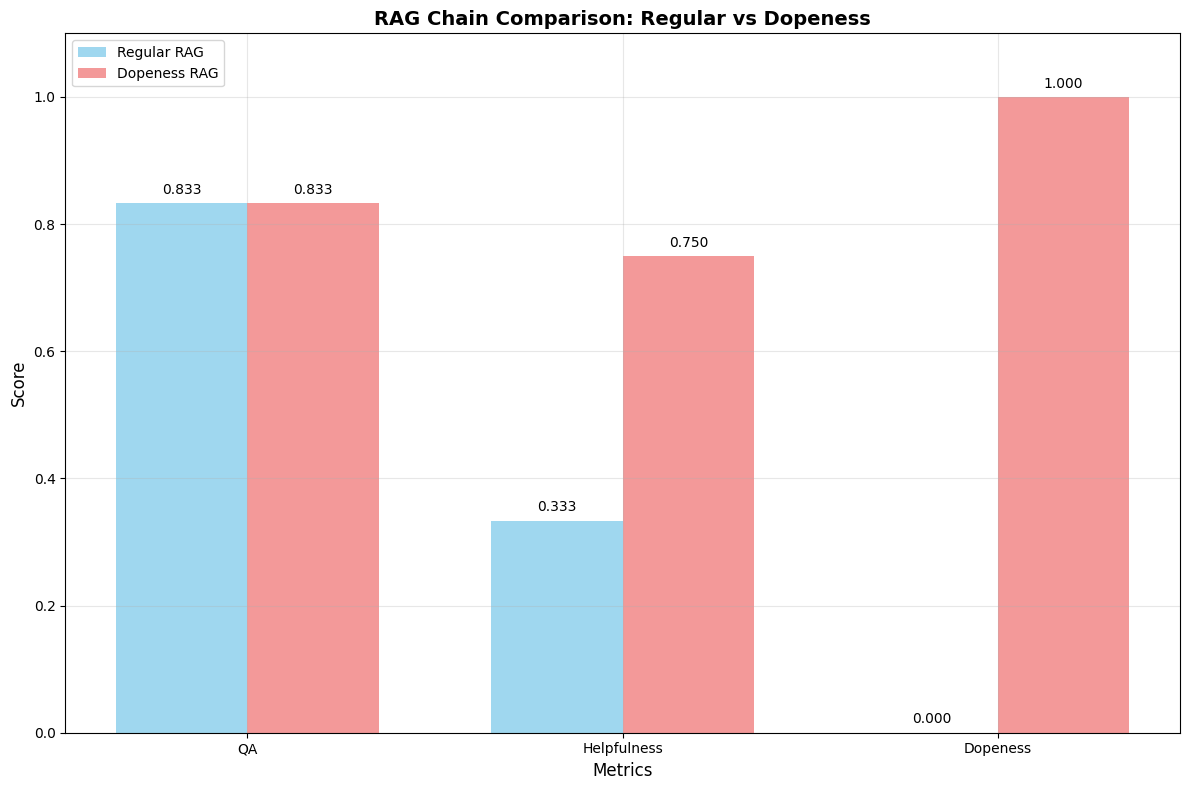

RAG Chain Comparison Results:
Metric          Regular RAG  Dopeness RAG Difference   Change  
----------------------------------------------------------------------
QA              0.833        0.833        0.000        =       
Helpfulness     0.333        0.750        0.417        ↑       
Dopeness        0.000        1.000        1.000        ↑       


In [64]:

# Convert to pandas DataFrames
regular_df = regular_eval.to_pandas()
dopeness_df = dopeness_eval.to_pandas()

# Calculate average scores for each metric
regular_scores = {
    'QA': regular_df['feedback.correctness'].mean(),
    'Helpfulness': regular_df['feedback.helpfulness'].mean(),
    'Dopeness': regular_df['feedback.dopeness'].mean()
}

dopeness_scores = {
    'QA': dopeness_df['feedback.correctness'].mean(),
    'Helpfulness': dopeness_df['feedback.helpfulness'].mean(),
    'Dopeness': dopeness_df['feedback.dopeness'].mean()
}

# Create comparison dataframe
comparison_data = {
    'Metric': ['QA', 'Helpfulness', 'Dopeness'],
    'Regular RAG': [regular_scores['QA'], regular_scores['Helpfulness'], regular_scores['Dopeness']],
    'Dopeness RAG': [dopeness_scores['QA'], dopeness_scores['Helpfulness'], dopeness_scores['Dopeness']]
}

df = pd.DataFrame(comparison_data)

# Create side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Set up the bar positions
x = range(len(df['Metric']))
width = 0.35

# Create bars
bars1 = ax.bar([i - width/2 for i in x], df['Regular RAG'], width, label='Regular RAG', alpha=0.8, color='skyblue')
bars2 = ax.bar([i + width/2 for i in x], df['Dopeness RAG'], width, label='Dopeness RAG', alpha=0.8, color='lightcoral')

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

# Customize the chart
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('RAG Chain Comparison: Regular vs Dopeness', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Metric'])
ax.legend()
ax.grid(True, alpha=0.3)

# Set y-axis limits
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Print the comparison table
print("RAG Chain Comparison Results:")
print("=" * 60)
print(f"{'Metric':<15} {'Regular RAG':<12} {'Dopeness RAG':<12} {'Difference':<12} {'Change':<8}")
print("-" * 70)

for metric in ['QA', 'Helpfulness', 'Dopeness']:
    regular_score = regular_scores[metric]
    dopeness_score = dopeness_scores[metric]
    difference = dopeness_score - regular_score
    change = "↑" if difference > 0 else "↓" if difference < 0 else "="
    
    print(f"{metric:<15} {regular_score:<12.3f} {dopeness_score:<12.3f} {difference:<12.3f} {change:<8}")

print("=" * 70)